# Time Series Analysis in Python

##  Learning Outcomes

After this video, you'll be able to:

<ul>
    <li>Set up a time series analysis environment in AWS</li>
    <li>Build forecasting models using ARIMA and Prophet</li>
    <li>Compare and evaluate prediction accuracy</li>
    <li>Choose appropriate models for different business scenarios</li>
</ul>

## Environment Setup

In [2]:
!pip install prophet

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from statsmodels.tsa.stattools import adfuller

## Data Preparation

In [5]:
# For ARIMA analysis
df_arima = pd.read_csv('insightlysoft_company_metrics_5years.csv')
print(df_arima.head())
df_arima['date'] = pd.to_datetime(df_arima['date'])
df_arima.set_index('date', inplace=True)
df_arima = df_arima.asfreq('D')

         date       revenue  unique_users  leads        costs
0  2019-01-01  13798.778226          1270     36  3000.000000
1  2019-01-02  13537.548303          1494     26  3000.000000
2  2019-01-03  13984.391938          1388     28  3000.000000
3  2019-01-04  14473.529463          1449     30  7274.817383
4  2019-01-05  12893.998903          1360     32  7086.096362


In [6]:
# For Prophet analysis
df_prophet = df_arima.reset_index()
df_prophet.columns = ['ds', 'y'] + list(df_prophet.columns[2:])

## ARIMA Implementation

In [7]:
result = adfuller(df_arima['revenue'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -3.016410327948886
p-value: 0.03339004306139738


In [8]:
model = ARIMA(df_arima['revenue'], order=(1, 0, 1))  # ARIMA(p=1, d=0, q=1)
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                revenue   No. Observations:                 1826
Model:                 ARIMA(1, 0, 1)   Log Likelihood              -14552.720
Date:                Wed, 30 Jul 2025   AIC                          29113.440
Time:                        22:54:44   BIC                          29135.480
Sample:                    01-01-2019   HQIC                         29121.570
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.881e+04   2.77e-10   6.79e+13      0.000    1.88e+04    1.88e+04
ar.L1          0.9999      0.000   3221.583      0.000       0.999       1.000
ma.L1         -0.6944      0.018    -39.480      0.0

In [9]:
forecast = model_fit.forecast(steps=90)

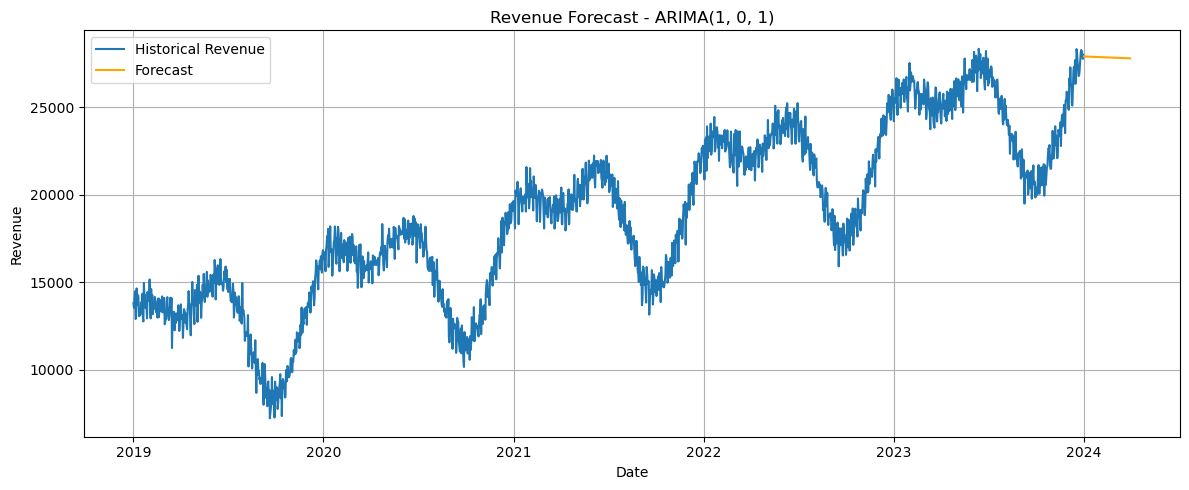

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(df_arima['revenue'], label='Historical Revenue')
plt.plot(forecast.index, forecast, label='Forecast', color='orange')
plt.title("Revenue Forecast - ARIMA(1, 0, 1)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Prophet Implementation

In [11]:
model = Prophet(yearly_seasonality=True, 
               weekly_seasonality=True)
model.fit(df_prophet)

22:56:36 - cmdstanpy - INFO - Chain [1] start processing
22:56:36 - cmdstanpy - INFO - Chain [1] done processing


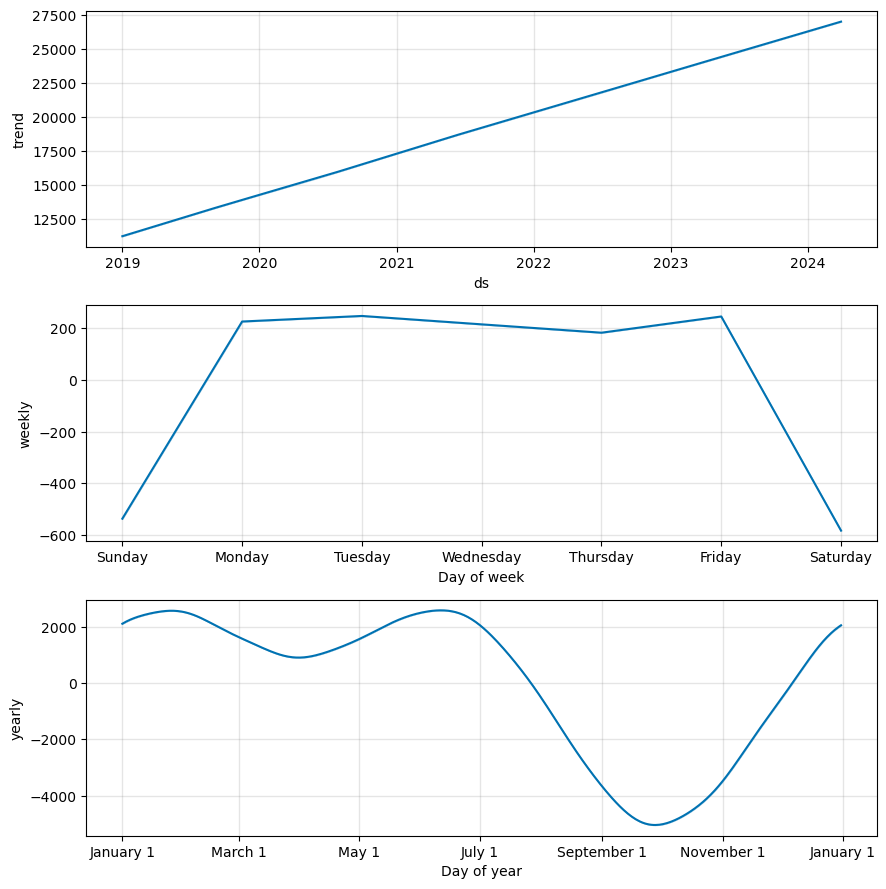

In [12]:
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)
fig = model.plot_components(forecast)

## Model Evaluation

In [13]:
def calculate_metrics(actual, predicted):
    
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mape = np.mean(np.abs((actual - predicted)/actual)) * 100
    
    return mae, rmse, mape

In [14]:
df_eval = forecast.set_index('ds').join(df_prophet.set_index('ds'), rsuffix='_actual')
df_eval = df_eval.dropna(subset=['y', 'yhat'])
mae, rmse, mape = calculate_metrics(df_eval['y'], df_eval['yhat'])
print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAPE: {mape:.2f}%")

MAE: 389.797
RMSE: 490.318
MAPE: 2.24%


## Recap


In this video, we covered:

- Environment setup in AWS SageMaker AI 

- Time series data preparation 

- ARIMA and Prophet implementation 

- Model evaluation techniques
